Run the command below in a PyCharm WSL window to access the Python virtual environment:

```shell
 source /home/penguini/.virtualenvs/DrChanWorkPlayground/bin/activate
```

In [ ]:
import tensorflow as tf

# List available physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

# If GPUs are found, check if TensorFlow is built with CUDA/ROCm support
if len(physical_devices) > 0:
    print("TensorFlow is built with GPU support:", tf.test.is_built_with_cuda())

In [2]:
import numpy as np
import keras
from keras import layers
from tensorflow.keras.datasets import fashion_mnist
import imbal.metrics

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print(y_train[:50])
y_train = np.array([1 if y_train[i] == 0 else 0 for i in range(len(y_train))])
print(y_train[:50])

y_test = np.array([1 if y_test[i] == 0 else 0 for i in range(len(y_test))])

[9 0 0 3 0 2 7 2 5 5 0 9 5 5 7 9 1 0 6 4 3 1 4 8 4 3 0 2 4 4 5 3 6 6 0 8 5
 2 1 6 6 7 9 5 9 2 7 3 0 3]
[0 1 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0]


In [3]:
inputs = keras.Input(shape=(28,28))
flatten = layers.Flatten()(inputs)
hidden = layers.Dense(64, activation='relu')(flatten)
output = layers.Dense(1, activation='sigmoid')(hidden)

model = keras.Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy", 'tpr', 'false_positive_rate', 'tnr', 'expected_TP', 'expected_tn', 'EC', 'tss', 'hss', 'gs', 'critical_success_index'])

I0000 00:00:1756388983.677082  100614 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9556 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
history = model.fit(x_train, y_train, batch_size=256, epochs=5)

Epoch 1/5


2025-08-28 09:49:45.190555: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f39cc011920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-08-28 09:49:45.190577: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-08-28 09:49:45.227207: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-08-28 09:49:45.352368: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91200
2025-08-28 09:49:45.558732: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_192', 4 bytes spill stores, 4 bytes spill loads



 52/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - EC: 5479.3877 - accuracy: 0.8353 - critical_success_index: 0.2350 - expected_TP: 78.1841 - expected_tn: 5401.2031 - false_positive_rate: 0.1182 - gs: 0.1795 - hss: 0.2843 - loss: 18.8855 - tnr: 0.8818 - tpr: 0.4184 - tss: 0.3002

I0000 00:00:1756388985.924840  100849 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


233/235 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - EC: 24457.9551 - accuracy: 0.9070 - critical_success_index: 0.4226 - expected_TP: 312.2783 - expected_tn: 24145.6777 - false_positive_rate: 0.0597 - gs: 0.3771 - hss: 0.5332 - loss: 7.6142 - tnr: 0.9403 - tpr: 0.6063 - tss: 0.5466

2025-08-28 09:49:46.698234: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-08-28 09:49:47.030949: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_594', 12 bytes spill stores, 12 bytes spill loads



235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - EC: 49016.7969 - accuracy: 0.9332 - critical_success_index: 0.5064 - expected_TP: 622.9000 - expected_tn: 48393.8984 - false_positive_rate: 0.0392 - gs: 0.4654 - hss: 0.6352 - loss: 2.7619 - tnr: 0.9608 - tpr: 0.6852 - tss: 0.6459
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - EC: 49129.5977 - accuracy: 0.9449 - critical_success_index: 0.5707 - expected_TP: 608.8000 - expected_tn: 48520.7969 - false_positive_rate: 0.0314 - gs: 0.5338 - hss: 0.6961 - loss: 0.6280 - tnr: 0.9686 - tpr: 0.7320 - tss: 0.7006
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - EC: 49149.6016 - accuracy: 0.9477 - critical_success_index: 0.5874 - expected_TP: 606.3000 - expected_tn: 48543.3008 - false_positive_rate: 0.0296 - gs: 0.5517 - hss: 0.7111 - loss: 0.4592 - tnr: 0.9704 - tpr: 0.7440 - tss: 0.7144
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - EC: 49142.4023 - accuracy: 0.9504 - critical_success_index: 0.6043 - expected_TP: 607.2000 - expected_tn:

In [5]:
test_scores = model.evaluate(x_test, y_test, verbose=1, batch_size=250)
print("Test loss:", test_scores[0])
print(x_test.shape[0])

 1/40 ━━━━━━━━━━━━━━━━━━━━ 20s 517ms/step - EC: 208.2000 - accuracy: 0.9760 - critical_success_index: 0.7692 - expected_TP: 2.1000 - expected_tn: 206.1000 - false_positive_rate: 0.0044 - gs: 0.7490 - hss: 0.8565 - loss: 0.1584 - tnr: 0.9956 - tpr: 0.8000 - tss: 0.7956

2025-08-28 09:49:58.600291: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_128', 8 bytes spill stores, 8 bytes spill loads



40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - EC: 8360.8008 - accuracy: 0.9517 - critical_success_index: 0.5767 - expected_TP: 79.9000 - expected_tn: 8280.9004 - false_positive_rate: 0.0157 - gs: 0.5448 - hss: 0.7053 - loss: 0.3268 - tnr: 0.9843 - tpr: 0.6580 - tss: 0.6423
Test loss: 0.3268095850944519
10000


In [6]:
print(model.predict(np.reshape(x_test[12], (1, 28, 28))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
[[0.]]


In [7]:
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])
print("Test TPR:", test_scores[2])
print("Test FPR:", test_scores[3])
print("Test TNR:", test_scores[4])
print("Test Expected TP:", test_scores[5])
print("Test Expected TN:", test_scores[6])
print("Test Expected Correct:", test_scores[7])
print("Test TSS:", test_scores[8])
print("Test HSS:", test_scores[9])
print("Test GS:", test_scores[10])
print("Test CSI:", test_scores[1])

Test loss: 0.3268095850944519
Test accuracy: 0.95169997215271
Test TPR: 0.6579999923706055
Test FPR: 0.015666667371988297
Test TNR: 0.984333336353302
Test Expected TP: 79.9000015258789
Test Expected TN: 8280.900390625
Test Expected Correct: 8360.80078125
Test TSS: 0.6423333287239075
Test HSS: 0.7053439021110535
Test GS: 0.5448119640350342
Test CSI: 0.95169997215271


In [14]:
print(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
T-shirt/top


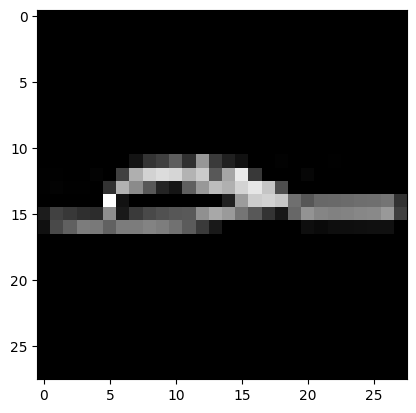

In [15]:
import matplotlib.pyplot as plt

labels = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

data_index = 8


plt.imshow(x_test[data_index], cmap=plt.get_cmap('gray'))
print(labels[np.argmax(model.predict(np.reshape(x_test[data_index], (1, 28, 28))))])


In [ ]:
import tensorflow as tf

# List available physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

# If GPUs are found, check if TensorFlow is built with CUDA/ROCm support
if len(physical_devices) > 0:
    print("TensorFlow is built with GPU support:", tf.test.is_built_with_cuda())

In [ ]:
import numpy as np
import keras
from keras import layers
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
inputs = keras.Input(shape=(28,28))
flatten = layers.Flatten()(inputs)
hidden = layers.Dense(64, activation='relu')(flatten)
output = layers.Dense(10, activation='softmax')(hidden)

model = keras.Model(inputs=inputs, outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, batch_size=256, epochs=20, validation_data=(x_test, y_test))

In [ ]:
test_scores = model.evaluate(x_test, y_test, verbose=1)

In [ ]:
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

In [ ]:
print(history)

In [ ]:
import matplotlib.pyplot as plt

data_index = 12


plt.imshow(x_test[data_index], cmap=plt.get_cmap('gray'))
print(np.argmax(model.predict(np.reshape(x_test[data_index], (1, 28, 28)))))
